## Ausarbeitung der Analyse mit Decision Tree für den Datensatz diabetes_binary_5050split_health_indicators_BRFSS2015

Der Datensatz diabetes_binary_5050split_health_indicators_BRFSS2015 wird ab sofort df_5050_01 genannt

Die Spalte Targetspalte (index = 0) wird von Diabebetes_binary in Diabetes geändert

## Laden des Datensatz

In [34]:
dataSetPath = "Datensatz/diabetes_binary_5050split_health_indicators_BRFSS2015.csv"
random_state = 42
test_size = 0.2

max_depth=5
min_samples_split=20

In [18]:


import pandas as pd

# CSV laden
df = pd.read_csv(dataSetPath)


In [19]:
# Erste Zeilen anschauen
print(df.head())
# Infos und Beschreibung ausgeben
print(df.info())
print(df.describe())

   Diabetes  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0       0.0     1.0       0.0        1.0  26.0     0.0     0.0   
1       0.0     1.0       1.0        1.0  26.0     1.0     1.0   
2       0.0     0.0       0.0        1.0  26.0     0.0     0.0   
3       0.0     1.0       1.0        1.0  28.0     1.0     0.0   
4       0.0     0.0       0.0        1.0  29.0     1.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           1.0     0.0  ...            1.0   
1                   0.0           0.0     1.0  ...            1.0   
2                   0.0           1.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      3.0       5.0      30.0       0.0  1.0   4.0        6.0   
1          0.0      3.0       

 Eine vorherige Datenanalyse hat gezeigt das es keine Null Werte gibt. Datensatz ist vollständig

## Trennen in Target (y) und Feature Values (X)

In [20]:
# Targetvalue von Feature trennen
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

## Daten in Trainings und Testdaten aufteilen

In [21]:
from sklearn.model_selection import train_test_split

# Trainingsdaten und Testdaten trennen
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=random_state
)

## Decision Tree Modell erstellen

In [22]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
importances = pd.Series(model.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

HighBP                  0.148169
BMI                     0.133938
GenHlth                 0.099941
Age                     0.096530
Income                  0.088808
PhysHlth                0.072129
Education               0.060467
MentHlth                0.056801
Smoker                  0.031263
Sex                     0.029439
Fruits                  0.029371
PhysActivity            0.025329
Veggies                 0.022985
HighChol                0.021558
DiffWalk                0.019928
HeartDiseaseorAttack    0.018092
NoDocbcCost             0.012250
Stroke                  0.011413
HvyAlcoholConsump       0.008985
AnyHealthcare           0.007969
CholCheck               0.004635
dtype: float64


## Evaluierung des Modells

In [24]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6493387085366716
              precision    recall  f1-score   support

         0.0       0.65      0.65      0.65      7090
         1.0       0.65      0.65      0.65      7049

    accuracy                           0.65     14139
   macro avg       0.65      0.65      0.65     14139
weighted avg       0.65      0.65      0.65     14139



In [25]:
## Prüfen ob Overfitting

In [26]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.9951373048290983
Test Accuracy: 0.6493387085366716


Train >> Test → Overfitting liegt vor

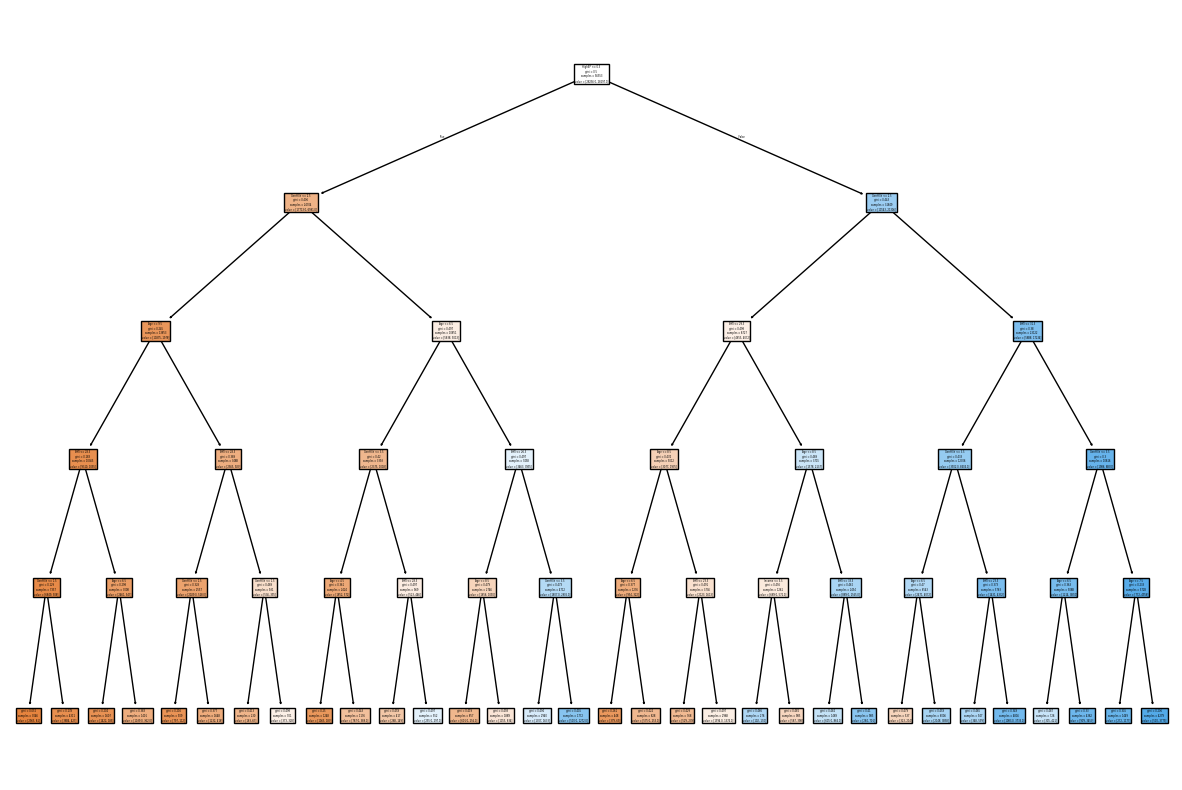

In [39]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(model, feature_names=top_features, filled=True)
plt.show()

In [ ]:
Decision Tree zeigt viele Blätter und ist relativ tief

## Top 6 Features auswählen

In [27]:
top_features = ["HighBP", "BMI", "GenHlth", "Age", "Income", "PhysHlth"]
# Education korreliert zu einkommen. daher nehme ich das nichjt mit rein

## Reduktion des Datensatzes

In [31]:
X_top = X[top_features]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=test_size, random_state=random_state
)

In [35]:
model = DecisionTreeClassifier(
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    random_state=random_state
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,20
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [36]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7347054247117901
              precision    recall  f1-score   support

         0.0       0.76      0.69      0.72      7090
         1.0       0.72      0.77      0.74      7049

    accuracy                           0.73     14139
   macro avg       0.74      0.73      0.73     14139
weighted avg       0.74      0.73      0.73     14139



In [37]:
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.7355754778703163
Test Accuracy: 0.7347054247117901


kein Overfitting mehr

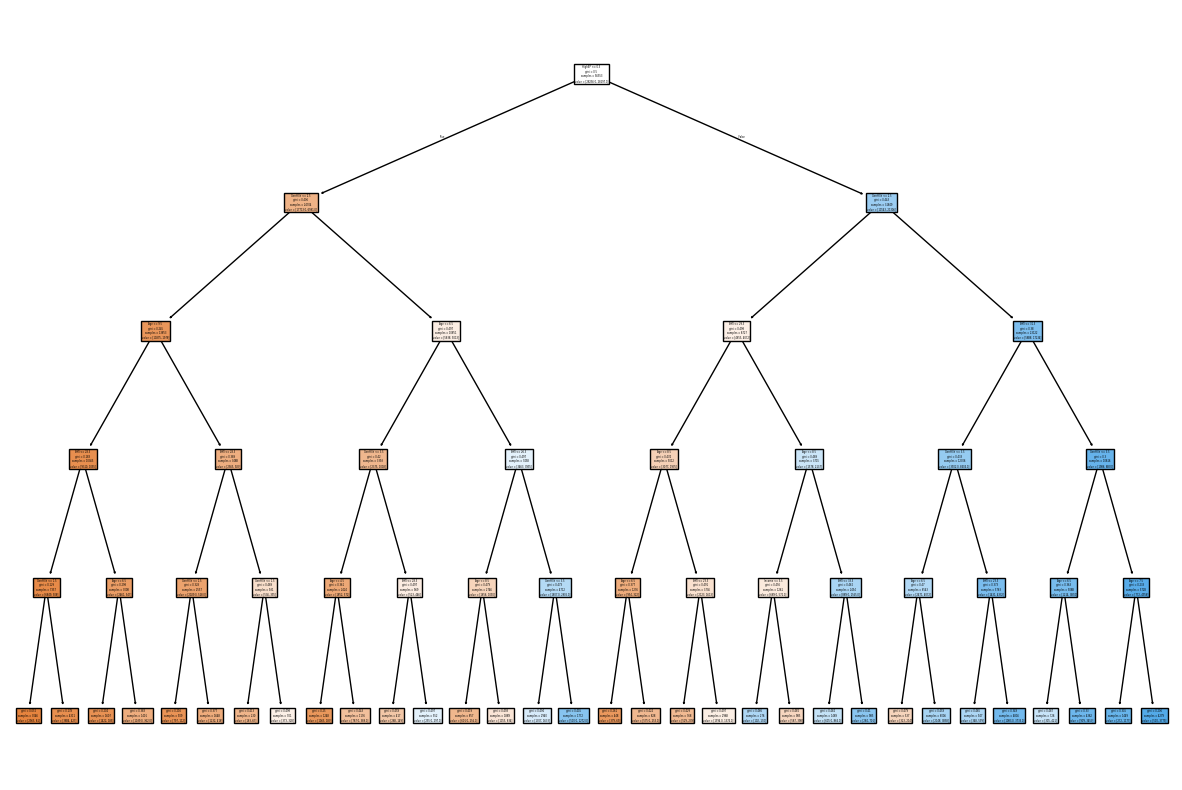

In [38]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))
plot_tree(model, feature_names=top_features, filled=True)
plt.show()

In [ ]:
Decision Tree zeigt viele Blätter und ist relativ tief -> Keine Wirkliche verbesseung